# Chapter 3.5: Sequential Retrieval

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Implement** SASRec (Self-Attentive Sequential Recommendation) for retrieval
2. **Understand** BERT4Rec's bidirectional encoding approach
3. **Build** session-based retrieval for anonymous users
4. **Compare** user history encoding strategies: recent-N, attention-weighted, time-decay
5. **Apply** positional encodings for sequence modeling in retrieval
6. **Train** and evaluate a sequential retrieval model on synthetic data
7. **Analyze** the effect of sequence length on retrieval quality

## Prerequisites

- Two-tower models (Chapter 3.1)
- Transformer / self-attention basics
- PyTorch fundamentals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part3/chapter_3.5_sequential_retrieval.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part3/chapter_3.5_sequential_retrieval.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, Optional

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cpu')
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.2.2


## 1. Why Sequential Retrieval?

Traditional two-tower models treat user history as a bag of items (order-invariant). But the **order** of interactions carries strong signal:

- Browsing `laptop → laptop case → mouse` suggests intent to buy laptop accessories
- Browsing `laptop → headphones → jacket` suggests casual browsing

Sequential models capture this temporal structure for better retrieval.

### Key Difference: Sequential vs. Non-Sequential

| Aspect | Non-Sequential (e.g., Two-Tower) | Sequential (e.g., SASRec) |
|--------|----------------------------------|---------------------------|
| Input | Bag of items | Ordered sequence |
| Architecture | Mean pooling / attention | Transformer / RNN |
| Captures | Overall preference | Evolving intent |
| Training | Contrastive / softmax | Next-item prediction |

> **💡 Concept:** Sequential retrieval is especially powerful for session-based scenarios where the user's current intent may differ significantly from their long-term profile.

In [2]:
# Generate synthetic sequential data with patterns
NUM_ITEMS = 3000
NUM_USERS = 500
NUM_CATEGORIES = 10
ITEMS_PER_CAT = NUM_ITEMS // NUM_CATEGORIES

# Create sequential interaction data with category-based patterns
def generate_sequential_data(num_users, num_items, num_categories,
                              min_seq_len=10, max_seq_len=50):
    """Generate user sequences with intra-sequence category coherence."""
    user_sequences = {}
    items_per_cat = num_items // num_categories
    
    for u in range(num_users):
        seq_len = np.random.randint(min_seq_len, max_seq_len)
        sequence = []
        
        # User has 2-3 interest phases per sequence
        n_phases = np.random.choice([2, 3])
        phase_lengths = np.random.dirichlet(np.ones(n_phases)) * seq_len
        phase_lengths = phase_lengths.astype(int)
        phase_lengths[-1] = seq_len - phase_lengths[:-1].sum()
        
        for phase_len in phase_lengths:
            cat = np.random.randint(0, num_categories)
            for _ in range(max(phase_len, 1)):
                # 85% from current category, 15% random
                if np.random.random() < 0.85:
                    item = cat * items_per_cat + np.random.randint(0, items_per_cat)
                else:
                    item = np.random.randint(0, num_items)
                sequence.append(item + 1)  # 0 is padding
        
        user_sequences[u] = sequence
    
    return user_sequences

user_sequences = generate_sequential_data(NUM_USERS, NUM_ITEMS, NUM_CATEGORIES)
print(f"Generated sequences for {NUM_USERS} users")
print(f"Avg sequence length: {np.mean([len(s) for s in user_sequences.values()]):.1f}")
print(f"Example sequence (first 10): {user_sequences[0][:10]}")

Generated sequences for 500 users
Avg sequence length: 29.5
Example sequence (first 10): [2015, 1888, 1952, 2058, 2094, 2077, 1822, 1849, 1970, 1988]


## 2. SASRec: Self-Attentive Sequential Recommendation

SASRec (Kang & McAuley, 2018) uses a **causal (left-to-right) Transformer** to encode the interaction sequence:

$$\mathbf{H} = \text{TransformerBlock}(\mathbf{E} + \mathbf{P})$$

where $\mathbf{E}$ is the item embedding matrix and $\mathbf{P}$ is positional encoding.

The causal mask ensures position $t$ can only attend to positions $\leq t$:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d}} + \mathbf{M}\right)V$$

where $M_{ij} = -\infty$ if $j > i$, else $0$.

The output at position $t$ serves as the user embedding for predicting item at $t+1$.

> **⚠️ Common Pitfall:** SASRec uses a causal mask (not bidirectional like BERT). This is crucial because at serving time, we can only attend to past items. Using a bidirectional mask during training would create a train-serve mismatch.

In [3]:
class SASRec(nn.Module):
    """Self-Attentive Sequential Recommendation (Kang & McAuley, 2018)."""
    
    def __init__(self, num_items: int, embed_dim: int = 64, max_len: int = 50,
                 num_heads: int = 2, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_len = max_len
        
        # Item embedding + positional embedding
        self.item_embedding = nn.Embedding(num_items + 1, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(embed_dim)
        
        # Transformer blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, 
            dim_feedforward=embed_dim * 4, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    
    def _generate_causal_mask(self, seq_len: int) -> torch.Tensor:
        """Generate causal attention mask."""
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        return mask
    
    def encode_sequence(self, item_seq: torch.Tensor, 
                        padding_mask: torch.Tensor = None) -> torch.Tensor:
        """
        Encode item sequence into user representation.
        
        Args:
            item_seq: (B, L) item ID sequence
            padding_mask: (B, L) True for padding positions
        
        Returns:
            (B, L, D) sequence of hidden states
        """
        B, L = item_seq.shape
        
        # Embeddings
        positions = torch.arange(L, device=item_seq.device).unsqueeze(0).expand(B, -1)
        x = self.item_embedding(item_seq) + self.pos_embedding(positions)
        x = self.layer_norm(self.dropout(x))
        
        # Causal mask
        causal_mask = self._generate_causal_mask(L).to(item_seq.device)
        
        # Transformer encoding
        output = self.transformer(
            x, mask=causal_mask,
            src_key_padding_mask=padding_mask
        )
        
        return output  # (B, L, D)
    
    def get_user_embedding(self, item_seq: torch.Tensor,
                           padding_mask: torch.Tensor = None) -> torch.Tensor:
        """Get user embedding from the last valid position."""
        hidden = self.encode_sequence(item_seq, padding_mask)  # (B, L, D)
        
        if padding_mask is not None:
            # Find last non-padding position
            lengths = (~padding_mask).sum(dim=1) - 1  # (B,)
            lengths = lengths.clamp(min=0)
            user_emb = hidden[torch.arange(hidden.size(0)), lengths]
        else:
            user_emb = hidden[:, -1]  # (B, D)
        
        return F.normalize(user_emb, p=2, dim=-1)
    
    def forward(self, item_seq, padding_mask=None):
        """Predict next item for each position."""
        hidden = self.encode_sequence(item_seq, padding_mask)  # (B, L, D)
        # Predict next item: use all item embeddings as the output layer
        logits = hidden @ self.item_embedding.weight.T  # (B, L, V)
        return logits


# Test
sasrec = SASRec(NUM_ITEMS, embed_dim=64, max_len=50, num_heads=2, num_layers=2)
print(f"SASRec parameters: {sum(p.numel() for p in sasrec.parameters()):,}")

# Forward pass
test_seq = torch.randint(1, NUM_ITEMS, (4, 30))
test_mask = torch.zeros(4, 30, dtype=torch.bool)
test_mask[:, 25:] = True  # last 5 positions are padding

logits = sasrec(test_seq, test_mask)
user_emb = sasrec.get_user_embedding(test_seq, test_mask)
print(f"Logits shape: {logits.shape}")
print(f"User embedding shape: {user_emb.shape}")

SASRec parameters: 295,360
Logits shape: torch.Size([4, 30, 3001])
User embedding shape: torch.Size([4, 64])


## 3. BERT4Rec: Bidirectional Encoding

BERT4Rec (Sun et al., 2019) uses **masked item prediction** instead of next-item prediction:

1. Randomly mask items in the sequence (replace with [MASK] token)
2. Predict the masked items using bidirectional context

$$P(v_t | \mathbf{v}_{\setminus t}) = \text{softmax}(\mathbf{h}_t^\top \mathbf{E})$$

At inference, append a [MASK] token at the end and predict the next item.

| Aspect | SASRec | BERT4Rec |
|--------|--------|----------|
| Training | Causal (left-to-right) | Masked (bidirectional) |
| Objective | Next-item prediction | Masked item prediction |
| Context | Past only | Past + future |
| Inference | Last hidden state | [MASK] at end |

> **🔑 Pro Tip:** BERT4Rec tends to work better with shorter sequences where bidirectional context helps. SASRec is better for longer sequences and streaming scenarios. For retrieval, SASRec is more common because the causal setup naturally aligns with the serving scenario.

In [4]:
class BERT4Rec(nn.Module):
    """BERT-style bidirectional sequential recommendation (Sun et al., 2019)."""
    
    def __init__(self, num_items: int, embed_dim: int = 64, max_len: int = 50,
                 num_heads: int = 2, num_layers: int = 2, dropout: float = 0.1,
                 mask_prob: float = 0.2):
        super().__init__()
        self.num_items = num_items
        self.mask_token = num_items + 1  # Special [MASK] token
        self.mask_prob = mask_prob
        self.embed_dim = embed_dim
        
        self.item_embedding = nn.Embedding(num_items + 2, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(embed_dim, num_items + 2)
    
    def mask_sequence(self, item_seq: torch.Tensor, padding_mask: torch.Tensor):
        """Apply random masking for training."""
        masked_seq = item_seq.clone()
        labels = torch.full_like(item_seq, -100)  # -100 = ignore
        
        for i in range(item_seq.size(0)):
            for j in range(item_seq.size(1)):
                if padding_mask[i, j]:
                    continue
                if np.random.random() < self.mask_prob:
                    labels[i, j] = item_seq[i, j]
                    if np.random.random() < 0.8:
                        masked_seq[i, j] = self.mask_token
                    elif np.random.random() < 0.5:
                        masked_seq[i, j] = np.random.randint(1, self.num_items + 1)
        
        return masked_seq, labels
    
    def forward(self, item_seq, padding_mask=None):
        B, L = item_seq.shape
        positions = torch.arange(L, device=item_seq.device).unsqueeze(0).expand(B, -1)
        
        x = self.item_embedding(item_seq) + self.pos_embedding(positions)
        x = self.layer_norm(self.dropout(x))
        
        # No causal mask — bidirectional attention
        output = self.transformer(x, src_key_padding_mask=padding_mask)
        logits = self.output_layer(output)  # (B, L, V)
        return logits
    
    def get_user_embedding(self, item_seq, padding_mask=None):
        """Append [MASK] and use its representation as user embedding."""
        B, L = item_seq.shape
        # Append MASK token
        mask_tokens = torch.full((B, 1), self.mask_token, dtype=torch.long, 
                                 device=item_seq.device)
        extended_seq = torch.cat([item_seq, mask_tokens], dim=1)
        
        if padding_mask is not None:
            extended_mask = torch.cat([padding_mask, 
                                       torch.zeros(B, 1, dtype=torch.bool, device=item_seq.device)], dim=1)
        else:
            extended_mask = None
        
        positions = torch.arange(L + 1, device=item_seq.device).unsqueeze(0).expand(B, -1)
        x = self.item_embedding(extended_seq) + self.pos_embedding(positions)
        x = self.layer_norm(self.dropout(x))
        output = self.transformer(x, src_key_padding_mask=extended_mask)
        
        return F.normalize(output[:, -1], p=2, dim=-1)

bert4rec = BERT4Rec(NUM_ITEMS, embed_dim=64, max_len=51)
print(f"BERT4Rec parameters: {sum(p.numel() for p in bert4rec.parameters()):,}")

BERT4Rec parameters: 490,618


## 4. User History Encoding Strategies

Different ways to aggregate a user's history into a query embedding for retrieval:

### Recent-N
Only use the last $N$ interactions. Simple and effective.

### Attention-Weighted
$$\mathbf{u} = \sum_i \alpha_i \mathbf{e}_i, \quad \alpha_i = \frac{\exp(\mathbf{e}_i^\top \mathbf{q})}{\sum_j \exp(\mathbf{e}_j^\top \mathbf{q})}$$

### Time-Decay
$$\alpha_i = \exp\left(-\lambda \cdot (t_{\text{now}} - t_i)\right)$$

More recent items get higher weight, with exponential decay.

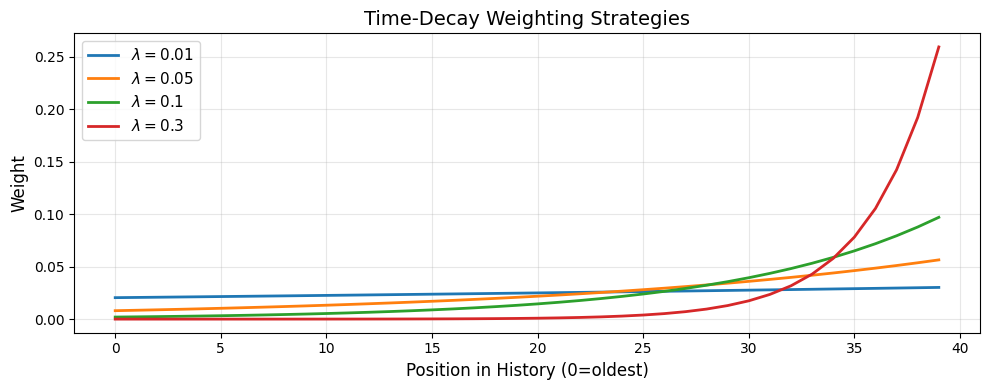

In [5]:
class HistoryEncoder(nn.Module):
    """Compare different history encoding strategies."""
    
    def __init__(self, num_items: int, embed_dim: int = 32):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items + 1, embed_dim, padding_idx=0)
        self.attn_query = nn.Parameter(torch.randn(embed_dim))
    
    def recent_n(self, history: torch.Tensor, mask: torch.Tensor, n: int = 10):
        """Use only last N items (mean pooling)."""
        B, L = history.shape
        # Zero out items beyond last N
        recent_mask = torch.zeros_like(mask)
        for i in range(B):
            valid_len = mask[i].sum().item()
            start = max(0, int(valid_len) - n)
            recent_mask[i, start:int(valid_len)] = True
        
        emb = self.item_embedding(history)  # (B, L, D)
        masked_emb = emb * recent_mask.unsqueeze(-1).float()
        summed = masked_emb.sum(dim=1)
        count = recent_mask.float().sum(dim=1, keepdim=True).clamp(min=1)
        return summed / count
    
    def attention_weighted(self, history: torch.Tensor, mask: torch.Tensor):
        """Attention-weighted aggregation."""
        emb = self.item_embedding(history)  # (B, L, D)
        scores = torch.matmul(emb, self.attn_query)  # (B, L)
        scores = scores.masked_fill(~mask, -1e9)
        weights = F.softmax(scores, dim=-1).unsqueeze(-1)  # (B, L, 1)
        return (emb * weights).sum(dim=1)
    
    def time_decay(self, history: torch.Tensor, mask: torch.Tensor, 
                   decay_rate: float = 0.1):
        """Time-decay weighted aggregation."""
        B, L = history.shape
        emb = self.item_embedding(history)  # (B, L, D)
        
        # Position-based decay (more recent = higher weight)
        positions = torch.arange(L, device=history.device).float()
        # Reverse: last position has weight 1, earlier positions decay
        weights = torch.exp(-decay_rate * (L - 1 - positions))  # (L,)
        weights = weights.unsqueeze(0).expand(B, -1)  # (B, L)
        weights = weights * mask.float()
        weights = weights / weights.sum(dim=1, keepdim=True).clamp(min=1e-8)
        
        return (emb * weights.unsqueeze(-1)).sum(dim=1)

# Compare strategies
encoder = HistoryEncoder(NUM_ITEMS, embed_dim=32)
test_hist = torch.randint(1, NUM_ITEMS, (8, 40))
test_mask = torch.ones(8, 40, dtype=torch.bool)
test_mask[:, 35:] = False

emb_recent = encoder.recent_n(test_hist, test_mask, n=10)
emb_attn = encoder.attention_weighted(test_hist, test_mask)
emb_decay = encoder.time_decay(test_hist, test_mask)

# Visualize time-decay weights
L = 40
decay_rates = [0.01, 0.05, 0.1, 0.3]
positions = np.arange(L)

plt.figure(figsize=(10, 4))
for rate in decay_rates:
    weights = np.exp(-rate * (L - 1 - positions))
    weights = weights / weights.sum()
    plt.plot(positions, weights, linewidth=2, label=f'$\\lambda={rate}$')

plt.xlabel('Position in History (0=oldest)', fontsize=12)
plt.ylabel('Weight', fontsize=12)
plt.title('Time-Decay Weighting Strategies', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Training SASRec for Retrieval

Epoch  5 | Loss: 17.7981


Epoch 10 | Loss: 13.6071


Epoch 15 | Loss: 11.0815


Epoch 20 | Loss: 9.7040


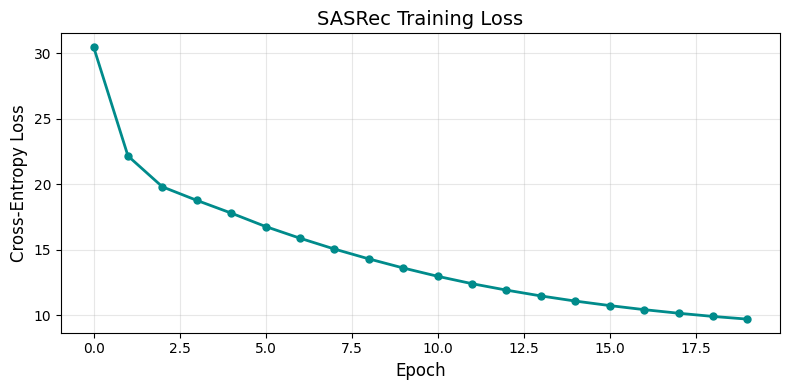

In [6]:
class SequentialDataset(Dataset):
    """Dataset for sequential recommendation training."""
    def __init__(self, user_sequences, max_len=50):
        self.samples = []
        self.max_len = max_len
        
        for u, seq in user_sequences.items():
            if len(seq) < 3:
                continue
            # Input: all but last, Target: all but first
            input_seq = seq[:-1][-max_len:]
            target_seq = seq[1:][-max_len:]
            self.samples.append((input_seq, target_seq))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        inp, tgt = self.samples[idx]
        L = len(inp)
        padded_inp = inp + [0] * (self.max_len - L)
        padded_tgt = tgt + [0] * (self.max_len - L)
        padding_mask = [False] * L + [True] * (self.max_len - L)
        
        return {
            'input': torch.tensor(padded_inp, dtype=torch.long),
            'target': torch.tensor(padded_tgt, dtype=torch.long),
            'padding_mask': torch.tensor(padding_mask, dtype=torch.bool)
        }

dataset = SequentialDataset(user_sequences, max_len=50)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Train SASRec
sasrec = SASRec(NUM_ITEMS, embed_dim=64, max_len=50, num_heads=2, num_layers=2)
optimizer = torch.optim.Adam(sasrec.parameters(), lr=1e-3)

losses = []
sasrec.train()

for epoch in range(20):
    epoch_loss = 0
    n_batch = 0
    for batch in dataloader:
        logits = sasrec(batch['input'], batch['padding_mask'])  # (B, L, V)
        
        # Next-item prediction loss
        logits_flat = logits.view(-1, logits.size(-1))
        targets_flat = batch['target'].view(-1)
        loss = F.cross_entropy(logits_flat, targets_flat, ignore_index=0)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sasrec.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batch += 1
    
    avg_loss = epoch_loss / n_batch
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses, 'o-', color='darkcyan', linewidth=2, markersize=5)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('SASRec Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Evaluate SASRec retrieval
sasrec.eval()

# Compute all item embeddings
with torch.no_grad():
    all_item_emb = sasrec.item_embedding.weight[1:]  # exclude padding
    all_item_emb = F.normalize(all_item_emb, p=2, dim=-1)

recall_at_k = {10: [], 50: [], 100: []}

for u in range(min(100, NUM_USERS)):
    seq = user_sequences[u]
    if len(seq) < 5:
        continue
    
    # Use all but last as input, last as target
    input_seq = seq[:-1][-50:]
    target = seq[-1] - 1  # Convert to 0-indexed
    
    padded = input_seq + [0] * (50 - len(input_seq))
    pad_mask = [False] * len(input_seq) + [True] * (50 - len(input_seq))
    
    with torch.no_grad():
        user_emb = sasrec.get_user_embedding(
            torch.tensor([padded]),
            torch.tensor([pad_mask])
        )
        scores = (user_emb @ all_item_emb.T).squeeze()
    
    for k in recall_at_k:
        top_k = scores.topk(k).indices.numpy()
        recall_at_k[k].append(1.0 if target in top_k else 0.0)

print("\nSASRec Retrieval Performance:")
for k, vals in recall_at_k.items():
    print(f"  Recall@{k:3d}: {np.mean(vals):.4f}")


SASRec Retrieval Performance:
  Recall@ 10: 0.0000
  Recall@ 50: 0.0200
  Recall@100: 0.0600


## 6. Session-Based Retrieval

For anonymous users without persistent histories, we use the current session only. GRU4Rec (Hidasi et al., 2016) was a pioneering approach using GRU-based sequence modeling.

> **💡 Concept:** Session-based retrieval is critical for e-commerce, news, and other domains where many users are anonymous. The model must quickly adapt to the user's intent from just a few interactions.

Session embedding shape: torch.Size([8, 64])


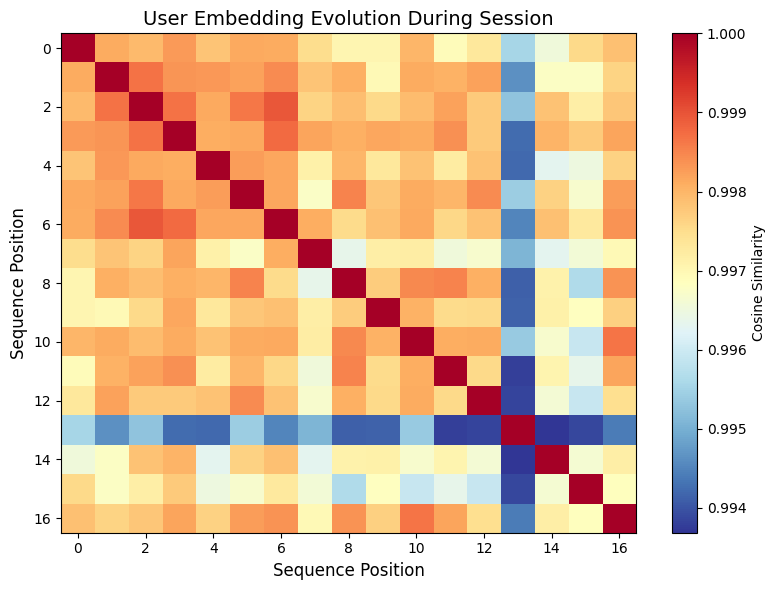

In [8]:
class SessionBasedRetrieval(nn.Module):
    """GRU-based session retrieval inspired by GRU4Rec (Hidasi et al., 2016)."""
    
    def __init__(self, num_items: int, embed_dim: int = 64, hidden_dim: int = 64):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items + 1, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, embed_dim)
    
    def forward(self, session_items: torch.Tensor, lengths: torch.Tensor):
        emb = self.item_embedding(session_items)
        
        # Pack padded sequences for efficiency
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        output, hidden = self.gru(packed)
        
        # Use last hidden state as session embedding
        session_emb = self.output_layer(hidden.squeeze(0))
        return F.normalize(session_emb, p=2, dim=-1)

session_model = SessionBasedRetrieval(NUM_ITEMS, embed_dim=64)
test_sessions = torch.randint(1, NUM_ITEMS, (8, 15))
test_lengths = torch.tensor([10, 12, 8, 15, 7, 11, 9, 13])

session_emb = session_model(test_sessions, test_lengths)
print(f"Session embedding shape: {session_emb.shape}")

# Visualize how embedding evolves within a session
sasrec.eval()
seq = user_sequences[0][:20]
embeddings_over_time = []

for t in range(3, len(seq)):
    sub_seq = seq[:t]
    padded = sub_seq + [0] * (50 - len(sub_seq))
    pad_mask = [False] * len(sub_seq) + [True] * (50 - len(sub_seq))
    
    with torch.no_grad():
        emb = sasrec.get_user_embedding(
            torch.tensor([padded]), torch.tensor([pad_mask])
        ).squeeze().numpy()
    embeddings_over_time.append(emb)

# Plot pairwise similarities
emb_array = np.array(embeddings_over_time)
sim_matrix = emb_array @ emb_array.T

plt.figure(figsize=(8, 6))
plt.imshow(sim_matrix, cmap='RdYlBu_r', aspect='auto')
plt.colorbar(label='Cosine Similarity')
plt.xlabel('Sequence Position', fontsize=12)
plt.ylabel('Sequence Position', fontsize=12)
plt.title('User Embedding Evolution During Session', fontsize=14)
plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Implement Position-Aware SASRec

Add time-aware positional encoding to SASRec where positions are based on actual timestamps rather than sequence indices.

In [9]:
class TimeAwareSASRec(nn.Module):
    """SASRec with time-aware positional encoding."""
    
    def __init__(self, num_items, embed_dim=64, max_len=50,
                 num_heads=2, num_layers=2, max_time_gap=1000):
        super().__init__()
        # TODO: Add time gap embedding
        # TODO: Modify positional encoding to use time gaps
        #       instead of sequential positions
        # TODO: Optionally add time-decay attention bias
        pass
    
    def forward(self, item_seq, time_gaps, padding_mask=None):
        # TODO: Combine item embeddings with time-gap embeddings
        # TODO: Apply transformer with time-aware attention
        pass

### 🏋️ Exercise 2: Compare Encoding Strategies

Train and evaluate all three history encoding strategies (recent-N, attention, time-decay) on the same data.

In [10]:
def compare_encoding_strategies(user_sequences, num_items, embed_dim=32):
    """
    Compare retrieval quality of different encoding strategies.
    
    Train each model and evaluate Recall@K on held-out data.
    
    Returns:
        Dict of {strategy: {k: recall}} metrics
    """
    # TODO: Create three models: recent-N, attention-weighted, time-decay
    # TODO: Train each with contrastive loss
    # TODO: Evaluate Recall@10, 50, 100
    # TODO: Plot comparison bar chart
    pass

### 🏋️ Exercise 3: Build a Hybrid Sequential + Profile Model

Combine SASRec's sequential encoding with static user profile features for a more powerful retrieval model.

In [11]:
class HybridSequentialRetrieval(nn.Module):
    """Combines sequential encoding with user profile."""
    
    def __init__(self, num_items, num_users, embed_dim=64,
                 max_len=50, num_heads=2, num_layers=2):
        super().__init__()
        # TODO: SASRec for sequential encoding
        # TODO: User profile embedding
        # TODO: Gating mechanism to combine sequential + profile
        pass
    
    def forward(self, user_id, item_seq, padding_mask):
        # TODO: Get sequential embedding from SASRec
        # TODO: Get user profile embedding
        # TODO: Combine with learned gate
        pass

# Hint: gate = sigmoid(W * concat(seq_emb, user_emb))
# output = gate * seq_emb + (1 - gate) * user_emb

### 🏋️ Exercise 4: Analyze Sequence Length Impact

Study how the length of user history affects SASRec's retrieval quality.

In [12]:
def analyze_sequence_length_impact(sasrec_model, user_sequences, num_items,
                                    length_buckets=[5, 10, 20, 30, 50]):
    """
    Evaluate retrieval quality at different history lengths.
    
    For each user, truncate history to different lengths and measure recall.
    
    Returns:
        Dict of {length: recall@K}
    """
    # TODO: For each length in length_buckets:
    #   1. Truncate each user's history to that length
    #   2. Compute user embedding and retrieve
    #   3. Measure Recall@10
    # TODO: Plot recall vs. sequence length
    pass

## Summary

| Model | Architecture | Training | Key Strength |
|-------|-------------|----------|--------------|
| **SASRec** | Causal Transformer | Next-item prediction | Best for long sequences, efficient serving |
| **BERT4Rec** | Bidirectional Transformer | Masked item prediction | Better for short sequences |
| **GRU4Rec** | GRU | Session-based BPR | Lightweight, fast |
| **Attention-Pool** | Attention over history | Contrastive | Simple, no positional info |
| **Time-Decay** | Exponential decay | Contrastive | Captures recency naturally |

**Next up**: Chapter 3.6 introduces Semantic ID Methods — a paradigm shift from opaque item IDs to meaningful token representations.